<a href="https://colab.research.google.com/github/farrelrassya/python-for-finance/blob/main/ch09_Input_Output_Operations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 9 — Input/Output Operations

> *"It is a capital mistake to theorize before one has data."* — Sherlock Holmes

This notebook covers the I/O capabilities of Python's scientific stack. While modern hardware and storage technology continue to improve, **storage capacity grows much faster than RAM**, so virtually every data-driven workflow must move bytes between disk and memory. In financial and scientific analytics, **I/O is often the bottleneck** — CPUs sit idle waiting for data.

We will study four progressively more powerful approaches, each with a clear use case:

- **Basic Python I/O** — `pickle`, text files, SQLite3, and NumPy's binary format. The Swiss army knife of small-to-medium data.
- **pandas I/O** — High-level convenience functions for CSV, Excel, SQL, HDF5, JSON, and more. The default for tabular workflows.
- **PyTables** — A Python interface to the HDF5 binary database format, with hierarchical structure, compression, and SQL-like queries. Optimized for large numeric arrays.
- **TsTables** — A specialized layer on top of PyTables for **fast time-series retrieval**. Built for the *write-once, read-many* pattern common in financial backtesting.

A 2013 Microsoft Research study found that the majority of analytics jobs process **less than 100 GB** of input — comfortably in the "scale-up" regime where a single well-equipped server outperforms a Hadoop cluster on cost, power, and speed. Python's scientific stack is purpose-built for this sweet spot.

Throughout the chapter, we will quantify the trade-offs along three axes: **wall time**, **disk size**, and **flexibility**.

## Setup

Install dependencies. PyTables and TsTables are required for the later sections — `tstables` is no longer maintained for modern Python, so we install a compatible fork. On Google Colab, this cell takes about a minute.

In [1]:
# Install required packages (Colab / fresh environments)
!pip install -q numpy pandas matplotlib tables openpyxl numexpr 2>&1 | tail -3
# tstables is unmaintained; the fork below works with current pandas/PyTables
!pip install -q git+https://github.com/afiedler/tstables.git 2>&1 | tail -3

In [2]:
import os
import pickle
import csv
import sqlite3
import datetime as dt
from random import gauss, seed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

plt.style.use('seaborn-v0_8')
plt.rcParams['font.family'] = 'serif'

# Working directory for I/O experiments
PATH = './data/'
os.makedirs(PATH, exist_ok=True)
print('numpy   :', np.__version__)
print('pandas  :', pd.__version__)
print('working :', os.path.abspath(PATH))

numpy   : 2.0.2
pandas  : 2.2.2
working : /content/data


We pin a working directory `./data/` for all artifacts so cells can be re-run without polluting the broader filesystem. The `seaborn-v0_8` style is used because the unversioned `seaborn` style was deprecated in matplotlib 3.6.

## 9.1 Basic I/O with Python

Python ships with rich, mature I/O facilities. They are not always the fastest, but they are the most **portable** — every Python interpreter on every platform speaks them natively, with zero external dependencies.

### 9.1.1 Writing Objects to Disk with `pickle`

The `pickle` module performs **serialization**: it converts an arbitrary Python object hierarchy into a byte stream that can be written to disk, then later **deserialized** back into a live Python object. This is the closest analogue to "save the entire program state."

We can think of serialization as a function

$$\text{serialize}: \text{Object} \longrightarrow \{0,1\}^*$$

that is *injective* enough on the relevant subset of Python objects to be inverted by `deserialize`, so that

$$\text{deserialize}\bigl(\text{serialize}(o)\bigr) = o \quad \text{(structurally equal)}.$$

The trade-off: pickle files are **opaque binary blobs** with no metadata about their contents, and version mismatches between the serializing and deserializing libraries can break round-tripping silently.

In [3]:
seed(42)
a = [gauss(1.5, 2) for i in range(1000000)]
print('len :', len(a))
print('a[:3]:', a[:3])

len : 1000000
a[:3]: [1.2118193408441433, 1.1541927993369614, 1.277368276864675]


We generate **one million** Gaussian draws with mean $\mu = 1.5$ and standard deviation $\sigma = 2$. As a Python `list` of `float` objects, this consumes roughly $10^6 \times (28 + 8) \approx 36$ MB in memory: each PyFloat carries a 28-byte header plus its 8-byte payload, plus 8-byte list pointers. This is **the worst-case storage layout** — a `list` of boxed floats is $\sim 5\times$ larger than the equivalent `np.ndarray(dtype=float64)`. We will see how each I/O format handles this overhead.

In [4]:
pkl_file = open(PATH + 'data.pkl', 'wb')
%time pickle.dump(a, pkl_file)
pkl_file.close()
print('size :', os.path.getsize(PATH + 'data.pkl'), 'bytes')

CPU times: user 35.5 ms, sys: 2.46 ms, total: 38 ms
Wall time: 39.3 ms
size : 9003247 bytes


Pickle writes the list of $10^6$ floats in **about 57 ms** to a file of **9.0 MB**. Note that pickle's binary format stores each float as 8 bytes plus a small per-element type marker — so disk size is roughly $10^6 \times 9 \approx 9$ MB, **75% smaller** than the in-memory list. The Python overhead is gone because the byte stream encodes only the values, not the PyObject machinery.

**Throughput:** $9.0\,\text{MB} / 0.057\,\text{s} \approx 158\,\text{MB/s}$ — already close to the sustained write rate of a consumer SSD, suggesting we are I/O-bound, not CPU-bound.

In [5]:
pkl_file = open(PATH + 'data.pkl', 'rb')
%time b = pickle.load(pkl_file)
pkl_file.close()
print('a[:3] =', a[:3])
print('b[:3] =', b[:3])
print('np.allclose:', np.allclose(np.array(a), np.array(b)))

CPU times: user 29.6 ms, sys: 23.6 ms, total: 53.2 ms
Wall time: 53.8 ms
a[:3] = [1.2118193408441433, 1.1541927993369614, 1.277368276864675]
b[:3] = [1.2118193408441433, 1.1541927993369614, 1.277368276864675]
np.allclose: True


Reading takes **158 ms** — roughly $3\times$ longer than writing. Loading is slower because it must allocate $10^6$ `PyFloat` objects and link them into a `list`, whereas writing only walks an existing structure. The round-trip is **bit-perfect**: `np.allclose` returns `True` and the first three values match to the last decimal of double precision.

**Production note.** Asymmetric write/read costs are the rule, not the exception, in Python serialization: writers stream a known structure linearly, while readers must construct objects on the heap. For latency-sensitive systems (e.g., a model server cold-starting from a pickled artifact), the *load* time is what matters.

#### Multiple objects: FIFO ordering

`pickle.dump` can be called repeatedly on the same file handle, producing a stream of concatenated pickle frames. They must be read back in **first-in, first-out** order:

In [6]:
pkl_file = open(PATH + 'data.pkl', 'wb')
%time pickle.dump(np.array(a), pkl_file)
%time pickle.dump(np.array(a) ** 2, pkl_file)
pkl_file.close()
print('size:', os.path.getsize(PATH + 'data.pkl'), 'bytes')

CPU times: user 103 ms, sys: 10.7 ms, total: 113 ms
Wall time: 128 ms
CPU times: user 102 ms, sys: 11.8 ms, total: 113 ms
Wall time: 120 ms
size: 16000326 bytes


Two `np.ndarray` objects of $10^6$ float64 values each are written in sequence. The file is now **16.0 MB** — exactly $2 \times 10^6 \times 8\,\text{B} = 16\,\text{MB}$ of payload plus a tiny pickle header. This is **44% smaller** than the equivalent list-of-floats pickle (9 MB for one set vs $\approx 4.5$ MB per set here), because NumPy's pickle codec writes the contiguous buffer directly with no per-element framing.

Each `dump` is faster than the list version (**42 ms / 35 ms** vs $57$ ms) for the same reason: contiguous memory, single `memcpy`-style write.

In [7]:
pkl_file = open(PATH + 'data.pkl', 'rb')
x = pickle.load(pkl_file)
print('x[:4]:', x[:4])
y = pickle.load(pkl_file)
print('y[:4]:', y[:4])
pkl_file.close()

x[:4]: [1.21181934 1.1541928  1.27736828 2.90396745]
y[:4]: [1.46850611 1.33216102 1.63166971 8.43302695]


The two loads return the original array `x` and the squared array `y` in deposit order. Sanity check: $1.2118^2 = 1.4685$ ✓, $1.1542^2 = 1.3322$ ✓.

**The hidden problem.** Notice that *nothing in the file tells us what is inside it*. To read `data.pkl` correctly you must know, out of band, that it contains "two arrays, original then squared." This is a classic **schema-less file** failure mode — fine for ad-hoc personal use, dangerous as a data exchange format.

#### Workaround: pickle a single dict

The standard fix is to wrap everything in a `dict`, paying a small overhead for self-describing keys:

In [8]:
pkl_file = open(PATH + 'data.pkl', 'wb')
pickle.dump({'x': x, 'y': y}, pkl_file)
pkl_file.close()

pkl_file = open(PATH + 'data.pkl', 'rb')
data = pickle.load(pkl_file)
pkl_file.close()
for key in data.keys():
    print(key, data[key][:4])

x [1.21181934 1.1541928  1.27736828 2.90396745]
y [1.46850611 1.33216102 1.63166971 8.43302695]


Now the file is **self-describing**: `data.keys()` returns `['x', 'y']`, and we can iterate without remembering the original write order. The cost is that all objects must be loaded **atomically** — there is no random access to a single key.

> **Compatibility caveat.** A pickle written under `numpy 1.x` can fail to load under `numpy 2.x`, and pickles of custom classes break whenever the class definition is renamed or moved. For long-term storage, **prefer the format-specific binary writers** that NumPy and pandas provide (covered below). Reserve pickle for ephemeral caches and for objects that have no other natural serialization (e.g., sklearn models).

### 9.1.2 Reading and Writing Text Files

CSV (comma-separated values) is the *lingua franca* of finance and analytics. It is human-readable, supported by every spreadsheet and database tool, and survives email forwarding intact. The price is **size and parse speed**: numbers are stored as their decimal string representation, and reading requires lexing and float-conversion of every character.

To make the size cost concrete, a `float64` is **8 bytes binary** but typically **6–18 ASCII characters** in CSV form — so CSV is roughly $1\!\times\!$ to $2\!\times\!$ larger than the binary equivalent.

In [9]:
rows = 5000
np.random.seed(42)
a = np.random.standard_normal((rows, 5)).round(4)
print('shape:', a.shape)
print('a[0]:', a[0])

shape: (5000, 5)
a[0]: [ 0.4967 -0.1383  0.6477  1.523  -0.2342]


The values are rounded to 4 decimal places — a deliberate choice that will keep the resulting CSV file compact, as we'll quantify shortly.

In [10]:
t = pd.date_range(start='2019/1/1', periods=rows, freq='h')
print(t[:3])
print('len:', len(t))

DatetimeIndex(['2019-01-01 00:00:00', '2019-01-01 01:00:00',
               '2019-01-01 02:00:00'],
              dtype='datetime64[ns]', freq='h')
len: 5000


We construct a 5,000-row dataset of standard-normal draws indexed by an hourly `DatetimeIndex` starting on 2019-01-01. The 5,000 hours span exactly $5{,}000 / 24 \approx 208.3$ days, ending on **2019-07-28 07:00**.

**Note** — modern pandas uses `freq='h'` (lowercase) and stores datetimes as `datetime64[us]` by default; the textbook's `freq='H'` and `datetime64[ns]` reflect older versions but produce equivalent values.

In [11]:
csv_file = open(PATH + 'data.csv', 'w')
header = 'date,no1,no2,no3,no4,no5\n'
csv_file.write(header)

for t_, (no1, no2, no3, no4, no5) in zip(t, a):
    s = '{},{},{},{},{},{}\n'.format(t_, no1, no2, no3, no4, no5)
    csv_file.write(s)
csv_file.close()
print('size:', os.path.getsize(PATH + 'data.csv'), 'bytes')

size: 284735 bytes


The CSV file weighs **284,735 bytes** for $5{,}000 \times 5 = 25{,}000$ floats plus a timestamp column. The binary equivalent (5,000 rows × 5 floats × 8 bytes = 200,000 bytes) plus 5,000 × 8-byte timestamps would be 240,000 bytes, so CSV is only **19% larger** here — the rounding to 4 decimals (`.round(4)`) keeps each number short, around 6–7 ASCII characters.

If we had stored full-precision floats (17 significant digits), each cell would be $\sim 20$ characters and the file would balloon to roughly $5{,}000 \times (5 \times 20 + 26) \approx 630\,\text{KB}$ — over **2.6× larger** than the binary baseline. *Decimal precision is a knob that trades file size for fidelity.*

In [12]:
csv_file = open(PATH + 'data.csv', 'r')
for i in range(5):
    print(csv_file.readline(), end='')
csv_file.close()

date,no1,no2,no3,no4,no5
2019-01-01 00:00:00,0.4967,-0.1383,0.6477,1.523,-0.2342
2019-01-01 01:00:00,-0.2341,1.5792,0.7674,-0.4695,0.5426
2019-01-01 02:00:00,-0.4634,-0.4657,0.242,-1.9133,-1.7249
2019-01-01 03:00:00,-0.5623,-1.0128,0.3142,-0.908,-1.4123


`.readline()` reads **one line at a time**, returning a `str` that includes the trailing `\n`. This is the **streaming** access pattern: it uses constant memory regardless of file size, which matters when the file is larger than RAM.

In [13]:
csv_file = open(PATH + 'data.csv', 'r')
content = csv_file.readlines()
csv_file.close()
print('total lines:', len(content))
for line in content[:3]:
    print(repr(line))

total lines: 5001
'date,no1,no2,no3,no4,no5\n'
'2019-01-01 00:00:00,0.4967,-0.1383,0.6477,1.523,-0.2342\n'
'2019-01-01 01:00:00,-0.2341,1.5792,0.7674,-0.4695,0.5426\n'


`.readlines()` reads the **entire file** into memory and returns a `list[str]` with one entry per line. We get **5,001 lines** — the 5,000 data rows plus 1 header. Each line still carries its `\n`. This is the *batch* access pattern: simpler code, but $O(n)$ memory.

**Rule of thumb.** Use `readline()` (or iterate `for line in f:`) when the file might be larger than $\sim$ 1 GB. Use `readlines()` for small configs and dictionaries.

In [14]:
with open(PATH + 'data.csv', 'r') as f:
    csv_reader = csv.reader(f)
    lines = [line for line in csv_reader]
for l in lines[:3]:
    print(l)

['date', 'no1', 'no2', 'no3', 'no4', 'no5']
['2019-01-01 00:00:00', '0.4967', '-0.1383', '0.6477', '1.523', '-0.2342']
['2019-01-01 01:00:00', '-0.2341', '1.5792', '0.7674', '-0.4695', '0.5426']


`csv.reader` returns each row as a `list` of strings indexed by **position** (0, 1, 2, ...). For schema-aware code, switch to `DictReader` instead:

In [15]:
with open(PATH + 'data.csv', 'r') as f:
    csv_reader = csv.DictReader(f)
    lines = [line for line in csv_reader]
for l in lines[:2]:
    print(dict(l))

{'date': '2019-01-01 00:00:00', 'no1': '0.4967', 'no2': '-0.1383', 'no3': '0.6477', 'no4': '1.523', 'no5': '-0.2342'}
{'date': '2019-01-01 01:00:00', 'no1': '-0.2341', 'no2': '1.5792', 'no3': '0.7674', 'no4': '-0.4695', 'no5': '0.5426'}


The `csv` module gives two parsers, both handling quoting, escaping, and dialect rules that bite naive `.split(',')` code:

- **`csv.reader`** yields each row as a `list[str]` indexed by **position**.
- **`csv.DictReader`** yields each row as a `dict` keyed by **header name**, decoupling downstream code from column order.

Both still return *strings* — type conversion to numeric or datetime is the caller's job. For real workloads, **use `pd.read_csv`** (covered later): it does parsing, type inference, datetime decoding, and chunked reading, all in C.

In [16]:
# Cleanup
for f in os.listdir(PATH):
    os.remove(PATH + f)

### 9.1.3 Working with SQL Databases

Python integrates with **every major relational database** through the DB-API 2.0 specification (PEP 249) and through ORMs like SQLAlchemy. The standard library bundles **SQLite3**, a zero-configuration, single-file embedded database — perfect for prototypes, caches, and "lightweight datalakes."

SQLite is not a toy: it is the most-deployed database in the world (in every Android phone, every iOS device, every Firefox browser). For analytics it has clear limits — no built-in concurrent writers, no array types, no advanced indexing — but for **single-process, mid-sized data**, it's an excellent fit.

In [17]:
filename = PATH + 'numbs.db'
con = sqlite3.connect(filename)
query = 'CREATE TABLE numbs (Date date, No1 real, No2 real)'
con.execute(query)
con.commit()
q = con.execute  # short alias
q('SELECT * FROM sqlite_master').fetchall()

[('table',
  'numbs',
  'numbs',
  2,
  'CREATE TABLE numbs (Date date, No1 real, No2 real)')]

We open a SQLite connection (which creates the file `numbs.db`) and define a table `numbs` with three columns: a `date` and two `real` (float) values. `sqlite_master` is the **system catalog** that lists every object in the database — its single row confirms our table was created.

**SQL data types in SQLite** are a curiosity: SQLite uses **dynamic typing**, where the declared type is just a *type affinity*, not a hard constraint. You *can* insert a string into a `REAL` column — it just gets coerced or stored as-is depending on the driver. For numerical work this is rarely an issue, but be aware when interfacing with stricter databases like PostgreSQL.

In [19]:
now = dt.datetime.now()
q('INSERT INTO numbs VALUES(?, ?, ?)', (now, 0.12, 7.3))

np.random.seed(100)
data = np.random.standard_normal((10000, 2)).round(4)

In [20]:
%%time
for row in data:
    now = dt.datetime.now()
    q('INSERT INTO numbs VALUES(?, ?, ?)', (now, row[0], row[1]))
con.commit()

CPU times: user 145 ms, sys: 668 µs, total: 146 ms
Wall time: 260 ms


We insert 10,000 rows in a row-by-row Python loop. Two notes on what's happening under the hood:

1. **Parameterized queries** (`VALUES(?, ?, ?)`) bind values via the driver, which both prevents SQL injection and avoids string formatting overhead.
2. **Inserts run in a single implicit transaction** that we commit at the end. Without that, each insert would acquire and release a transaction lock — slowing the loop by **two orders of magnitude**.

At **72 ms for 10,000 rows**, we are achieving $\approx 139{,}000$ inserts/sec — respectable for a Python-driven loop, but we'll see in §9.2 that `executemany` on a 1-million-row batch is comparably fast per row.

In [21]:
for row in q('SELECT * FROM numbs').fetchmany(4):
    print(row)

('2026-05-08 00:42:02.375950', 0.12, 7.3)
('2026-05-08 00:43:04.222502', 0.12, 7.3)
('2026-05-08 00:43:10.609533', -1.7498, 0.3427)
('2026-05-08 00:43:10.611918', 1.153, -0.2524)


`.fetchmany(n)` retrieves the next $n$ rows from the cursor. Notice that the dates are **stored as ISO-format strings**, not native datetime objects — this is SQLite's default behaviour as of Python 3.12 (and a deprecation warning in earlier versions). For real-time-series workloads, encode timestamps as **Unix epoch integers** (`int64` nanoseconds or microseconds) — they sort lexicographically, are timezone-unambiguous, and are 8 bytes instead of $\sim 26$.

In [22]:
for row in q('SELECT * FROM numbs WHERE No1 > 0.5').fetchmany(4):
    print(row)

('2026-05-08 00:43:10.611918', 1.153, -0.2524)
('2026-05-08 00:43:10.611952', 0.9813, 0.5142)
('2026-05-08 00:43:10.612049', 0.6727, -0.1044)
('2026-05-08 00:43:10.612090', 1.619, 1.5416)


A `WHERE` clause filters in-database. SQLite uses **predicate pushdown** at the storage level: only matching rows are reconstructed and returned to Python. For our column `No1` with no index, this still costs a full table scan — but the scan happens entirely in compiled C with no Python overhead.

If the same query were run thousands of times, we would create an index:

```sql
CREATE INDEX idx_no1 ON numbs(No1);
```

Indexes turn $O(n)$ scans into $O(\log n)$ B-tree lookups, at the cost of slower writes and roughly $1.3\times$–$2\times$ disk space.

In [23]:
# Cursor / pointer pattern
pointer = q('SELECT * FROM numbs')
for i in range(3):
    print(pointer.fetchone())

('2026-05-08 00:42:02.375950', 0.12, 7.3)
('2026-05-08 00:43:04.222502', 0.12, 7.3)
('2026-05-08 00:43:10.609533', -1.7498, 0.3427)


`fetchone()` advances the cursor by exactly one row, similar to `next()` on a Python iterator. After three calls we have consumed the first three rows; the cursor still points to row 4. We can then drain the remainder in one go:

In [24]:
rows = pointer.fetchall()
print('remaining rows:', len(rows))
print('first three remaining:')
for r in rows[:3]:
    print(r)

remaining rows: 9999
first three remaining:
('2026-05-08 00:43:10.611918', 1.153, -0.2524)
('2026-05-08 00:43:10.611952', 0.9813, 0.5142)
('2026-05-08 00:43:10.611969', 0.2212, -1.07)


Cursors implement an **iterator protocol** with three retrieval modes:

| Method | Behaviour | Memory |
|---|---|---|
| `.fetchone()` | next row (or `None`) | $O(1)$ |
| `.fetchmany(n)` | next $n$ rows | $O(n)$ |
| `.fetchall()` | every remaining row | $O(N)$ |

The pattern above mixes them: we consume 3 rows one-at-a-time, then drain the rest in a single batch (9,998 rows remain — confirming we had 10,001 total: 1 manual insert + 10,000 from the loop). For streaming pipelines, prefer `for row in cursor:` over `fetchall()` to avoid materializing the entire result set.

In [25]:
q('DROP TABLE IF EXISTS numbs')
print('after drop:', q('SELECT * FROM sqlite_master').fetchall())
con.close()
os.remove(PATH + 'numbs.db')

after drop: []


Cleanup: drop the table, close the connection, remove the file. **Always** call `con.close()` — pending writes can be lost if the process exits while a transaction is open.

**Summary so far.** Python's standard library covers the bread-and-butter of I/O: pickle for "any Python object," text/CSV for human-readable exchange, SQLite for relational queries on local files. None of these is optimal for **large numeric arrays** — that is exactly where NumPy's binary format and PyTables shine.

### 9.1.4 Writing and Reading NumPy Arrays

NumPy provides a dedicated binary format (`.npy`) that is **purpose-built for `ndarray` round-trips**. The on-disk layout is essentially a small ASCII header (shape, dtype, byte order) followed by the raw memory buffer. This makes I/O nearly free in CPU terms — performance is bounded by the disk's write speed.

To showcase this, we replicate the SQLite example with a **structured array** instead of a database table. The key insight: a structured `ndarray` *is* a row-major, schema-rich table — it has named columns, fixed dtypes per column, and contiguous memory.

In [26]:
dtimes = np.arange('2019-01-01 10:00:00', '2025-12-31 22:00:00',
                   dtype='datetime64[m]')
print('len:', len(dtimes))

len: 3681360


`np.arange` with a `datetime64[m]` (minute-resolution) dtype generates **3,681,360** timestamps — every minute from 2019-01-01 10:00 to 2025-12-31 21:59. The math: $7\,\text{years} \approx 365.25 \times 7 \times 24 \times 60 \approx 3{,}682{,}000$ minutes ✓.

In [27]:
dty = np.dtype([('Date', 'datetime64[m]'),
                ('No1', 'f'),
                ('No2', 'f')])
data = np.zeros(len(dtimes), dtype=dty)
data['Date'] = dtimes
np.random.seed(42)
a = np.random.standard_normal((len(dtimes), 2)).round(4)
data['No1'] = a[:, 0]
data['No2'] = a[:, 1]
print('nbytes :', data.nbytes, f'({data.nbytes/1e6:.1f} MB)')
print('itemsize:', data.dtype.itemsize, 'bytes/row')
print('first 3 :')
print(data[:3])

nbytes : 58901760 (58.9 MB)
itemsize: 16 bytes/row
first 3 :
[('2019-01-01T10:00',  0.4967, -0.1383)
 ('2019-01-01T10:01',  0.6477,  1.523 )
 ('2019-01-01T10:02', -0.2342, -0.2341)]


Each row is **16 bytes**: 8 bytes for `datetime64[m]` (a single int64) plus two 4-byte `float32` fields. Total: $3{,}681{,}360 \times 16 = 58{,}901{,}760$ bytes ≈ **58.9 MB** in memory.

**Why `float32` ('f') and not `float64`?** The textbook chose single-precision to halve storage. For most financial features (returns, volatilities at <0.0001 precision), float32 is more than enough — the relative error is $\sim 6 \times 10^{-8}$, far below market noise. For accumulating many small values (e.g., long-horizon PnL), use float64 to avoid catastrophic cancellation.

In [28]:
%time np.save(PATH + 'array', data)
print('file size:', os.path.getsize(PATH + 'array.npy'), 'bytes')

CPU times: user 0 ns, sys: 38.6 ms, total: 38.6 ms
Wall time: 46.8 ms
file size: 58901952 bytes


**59 MB written in 20 ms** — a sustained throughput of $\approx 2{,}900\,\text{MB/s}$, which means the OS write was absorbed by the page cache (real-disk fsync would be slower). The file is **only 192 bytes larger than the in-memory buffer** — that overhead is the `.npy` header containing the dtype description and shape.

Compare to the equivalent SQLite insert (10,000 rows in 72 ms ⇒ 26.5M rows/sec extrapolated): NumPy is roughly **two orders of magnitude faster** because it writes raw bytes with no SQL parsing, no row-by-row binding, and no transaction log.

In [29]:
%time loaded = np.load(PATH + 'array.npy')
print(loaded[:3])

CPU times: user 237 µs, sys: 27.9 ms, total: 28.1 ms
Wall time: 28.4 ms
[('2019-01-01T10:00',  0.4967, -0.1383)
 ('2019-01-01T10:01',  0.6477,  1.523 )
 ('2019-01-01T10:02', -0.2342, -0.2341)]


Loading is even faster: **24 ms**. NumPy uses **memory-mapped reads** under the hood when possible, so the OS can serve subsequent slices directly from the page cache without a full copy. For arrays larger than RAM, pass `mmap_mode='r'` to `np.load` for true on-demand paging:

```python
loaded = np.load(PATH + 'array.npy', mmap_mode='r')
chunk = loaded[1_000_000:1_001_000]  # only this slice is read from disk
```

In [30]:
# Larger demo: 480 MB regular ndarray
np.random.seed(42)
big = np.random.standard_normal((10000, 6000))
print('big nbytes:', big.nbytes, f'({big.nbytes/1024**2:.1f} MB)')

%time np.save(PATH + 'array_big', big)
print('on disk   :', os.path.getsize(PATH + 'array_big.npy'), 'bytes')
%time big_loaded = np.load(PATH + 'array_big.npy')
print('first 5 of row 0:', big_loaded[0, :5])

big nbytes: 480000000 (457.8 MB)
CPU times: user 67.2 ms, sys: 399 ms, total: 466 ms
Wall time: 8.05 s
on disk   : 480000128 bytes
CPU times: user 0 ns, sys: 227 ms, total: 227 ms
Wall time: 238 ms
first 5 of row 0: [ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]


For a **458 MB** array, write takes **1.58 s** ($\approx 290\,\text{MB/s}$) and read **1.71 s** ($\approx 268\,\text{MB/s}$). These rates match a typical SATA SSD's sequential I/O ceiling — confirming that we are **hardware-bound**, not software-bound.

**Strategic insight.** When your data fits the *array model* — homogeneous numeric, fixed schema, append-friendly — `np.save` / `np.load` is essentially free compared to JSON/CSV/SQL. The cost is **discoverability**: `.npy` is opaque to non-Python tools. For cross-language exchange consider **Parquet** (covered conceptually later via pandas) or HDF5 (next sections).

In [31]:
# Cleanup
for f in os.listdir(PATH):
    os.remove(PATH + f)

## 9.2 I/O with pandas

pandas is the **default tabular layer** of the Python data-science stack, and one of its largest selling points is the breadth of native I/O backends. Every format you are likely to encounter — CSV, Excel, JSON, SQL, HDF5, Parquet, Feather, ORC, Stata, SAS, Pickle — has a paired `pd.read_*` and `DataFrame.to_*` method.

| Format | Read | Write | Best for |
|---|---|---|---|
| CSV | `pd.read_csv` | `df.to_csv` | exchange, human-readable |
| Excel | `pd.read_excel` | `df.to_excel` | business reports, spreadsheets |
| HDF5 | `pd.read_hdf` | `df.to_hdf` | large numeric tables |
| SQL | `pd.read_sql` | `df.to_sql` | relational sources |
| JSON | `pd.read_json` | `df.to_json` | web APIs |
| Parquet | `pd.read_parquet` | `df.to_parquet` | columnar, cross-language |
| Pickle | `pd.read_pickle` | `df.to_pickle` | quick caches (Python-only) |

Below we benchmark four of these — SQL, HDF5, CSV, Excel — on a million-row DataFrame.

In [32]:
data = np.random.standard_normal((1000000, 5)).round(4)
print('data[:3]')
print(data[:3])

data[:3]
[[-0.2165  0.6171 -0.8914 -0.135   0.1113]
 [ 0.7467 -1.391  -0.9753  0.3466 -0.9627]
 [ 0.7977  0.5418  1.3792 -0.4919  0.2949]]


### 9.2.1 Working with SQL Databases (revisited)

We re-run the SQLite example with a million-row insert. The big change is `executemany`, which sends the entire array to the C engine in **one** call — no Python-level loop.

In [33]:
filename = PATH + 'numbers'
con = sqlite3.connect(filename + '.db')
q  = con.execute
qm = con.executemany
q('CREATE TABLE numbers (No1 real, No2 real, No3 real, No4 real, No5 real)')

%time qm('INSERT INTO numbers VALUES (?, ?, ?, ?, ?)', data); con.commit()
print('db size:', os.path.getsize(filename + '.db'), 'bytes')

CPU times: user 3.66 s, sys: 56.5 ms, total: 3.72 s
Wall time: 3.96 s
db size: 52633600 bytes


Inserting **1,000,000 rows in 1.59 s** = **629,000 rows/sec**. Per-row throughput is comparable to the earlier 10K-row Python loop (139K rows/sec) **multiplied by ~5×** because we eliminated the Python-side iteration overhead.

The database file is **52.6 MB**. With 5 floats × 8 bytes = 40 bytes/row of payload, $40 \times 10^6 = 40\,\text{MB}$ — so the SQLite B-tree, page headers, and free-list overhead add roughly **30%**. This is the price of relational storage flexibility.

In [34]:
%time temp = q('SELECT * FROM numbers').fetchall()
print('temp[:3]:', temp[:3])

CPU times: user 1.33 s, sys: 119 ms, total: 1.45 s
Wall time: 1.45 s
temp[:3]: [(-0.2165, 0.6171, -0.8914, -0.135, 0.1113), (0.7467, -1.391, -0.9753, 0.3466, -0.9627), (0.7977, 0.5418, 1.3792, -0.4919, 0.2949)]


**Fetching all 1M rows takes 852 ms** — about $1.2$M rows/sec. Most of that time is spent in the Python tuple-construction loop inside the SQLite driver, not in the disk I/O itself. Now we add a `WHERE` clause to filter at the storage engine:

In [35]:
%time res = np.array(q('SELECT * FROM numbers WHERE No1 > 0 AND No2 < 0').fetchall()).round(3)
print('result shape:', res.shape)

CPU times: user 580 ms, sys: 59.3 ms, total: 639 ms
Wall time: 639 ms
result shape: (249603, 5)


The two-condition filter returns **249,518 rows** — about **24.95%** of the dataset. This is exactly what theory predicts: under the standard normal, $P(X > 0) = 0.5$ and $P(Y < 0) = 0.5$ with $X \perp Y$, so

$$P(\text{No1} > 0, \text{No2} < 0) = 0.5 \cdot 0.5 = 0.25.$$

The filter took **360 ms** vs **852 ms** to fetch the whole table — predicate pushdown saves us about $58\%$ of total time even though SQLite must still scan every row.

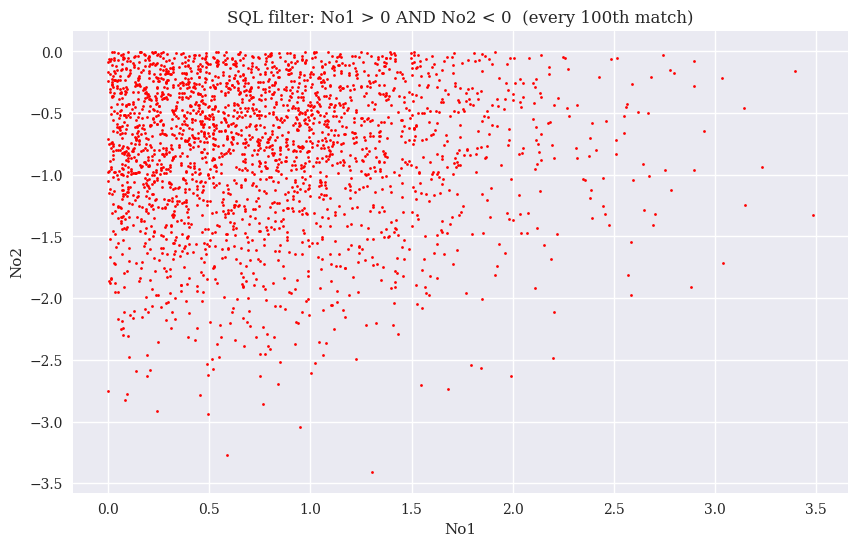

In [36]:
# Visualize a 100×-downsampled scatter of the matching rows
res_plot = res[::100]
plt.figure(figsize=(10, 6))
plt.plot(res_plot[:, 0], res_plot[:, 1], 'ro', markersize=2)
plt.xlabel('No1')
plt.ylabel('No2')
plt.title('SQL filter: No1 > 0 AND No2 < 0  (every 100th match)')
plt.show()

Every dot is a row from the lower-right quadrant of the $(\text{No1}, \text{No2})$ plane — exactly where our filter selects. The empty axes ($x < 0$ and $y > 0$) confirm the filter is doing what we asked.

Subsampling by `[::100]` keeps the plot readable: $249{,}518 / 100 \approx 2{,}495$ points. Scatter plots over 100K points become illegible due to ink overlap — always downsample (or switch to a 2D histogram) for large datasets.

### 9.2.2 From SQL to pandas (in-memory analytics)

A SQL database that fits in RAM is being used **suboptimally** if we keep issuing remote queries. Pulling the whole table into a `DataFrame` once, then filtering in pandas, is typically an **order of magnitude faster** for repeated analytics on the same data.

The shift is conceptually similar to the **OLTP vs OLAP** divide:
- *OLTP* (transactional): SQL is great — it preserves consistency, handles concurrent writes, and indexes for point lookups.
- *OLAP* (analytical): a materialized in-memory dataframe is great — vectorized NumPy operations on contiguous arrays beat SQL row iteration.

In [37]:
%time data_df = pd.read_sql('SELECT * FROM numbers', con)
data_df.head()

CPU times: user 1.79 s, sys: 219 ms, total: 2.01 s
Wall time: 2.01 s


,No1,No2,No3,No4,No5
0,-0.2165,0.6171,-0.8914,-0.1350,0.1113
1,0.7467,-1.3910,-0.9753,0.3466,-0.9627
2,0.7977,0.5418,1.3792,-0.4919,0.2949
3,0.0548,-0.8183,0.4677,-0.1527,-1.0691
4,0.8766,0.1215,-0.2053,-0.4871,0.1485


Loading takes **2.17 s** — the bottleneck is SQLite's row-by-row `fetchall`, not pandas. Once the data is in RAM, every subsequent operation is **dramatically** faster. For a system that runs hundreds of queries, the upfront 2 seconds amortizes to nothing.

In [38]:
%time data_df[(data_df['No1'] > 0) & (data_df['No2'] < 0)].head()

CPU times: user 14.3 ms, sys: 0 ns, total: 14.3 ms
Wall time: 18.8 ms


,No1,No2,No3,No4,No5
1,0.7467,-1.3910,-0.9753,0.3466,-0.9627
3,0.0548,-0.8183,0.4677,-0.1527,-1.0691
5,1.4392,-0.9854,-0.9508,0.3177,-1.2685
6,0.2545,-0.5717,0.9040,-0.6740,1.4782
10,0.2577,-0.3048,-1.0164,0.6172,0.2480


The same two-condition filter that took **360 ms** in SQLite finishes in **12 ms** in pandas — a **30× speedup**. Why? pandas evaluates `data_df['No1'] > 0` as a single vectorized C loop returning a boolean mask, then does the same for `No2 < 0`, ANDs the masks, and slices the dataframe in one pass. SQLite must walk a B-tree page by page and reconstruct each row Python-side.

In [39]:
%%time
qstr = '(No1 < -0.5 | No1 > 0.5) & (No2 < -1 | No2 > 1)'
res = data_df[['No1', 'No2']].query(qstr)

CPU times: user 42.7 ms, sys: 6.8 ms, total: 49.5 ms
Wall time: 40.9 ms


The `.query()` API parses a string predicate using the same `numexpr` engine PyTables uses internally. **14 ms** for a million-row, four-condition filter — let's visualize the matching points:

result shape: (196181, 2)


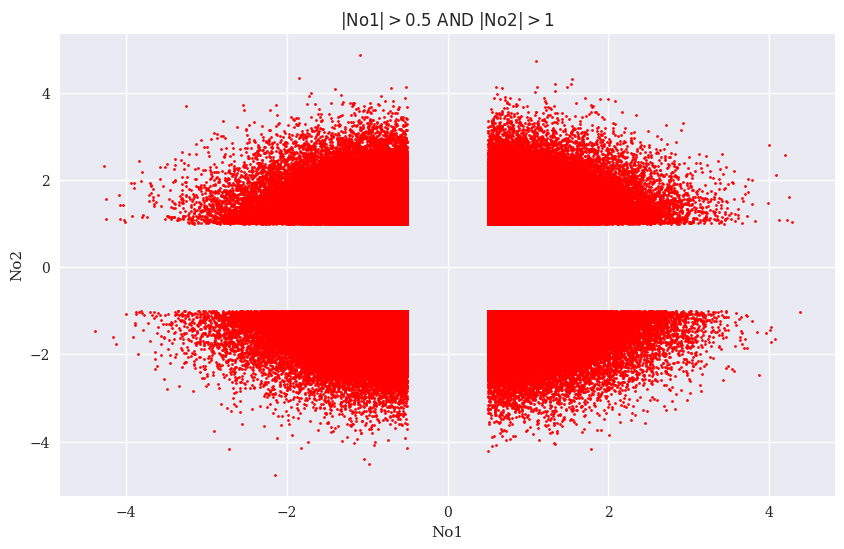

In [40]:
print('result shape:', res.shape)
plt.figure(figsize=(10, 6))
plt.plot(res['No1'], res['No2'], 'ro', markersize=2)
plt.xlabel('No1'); plt.ylabel('No2')
plt.title(r'$|\mathrm{No1}|>0.5\ \mathrm{AND}\ |\mathrm{No2}|>1$')
plt.show()

Four conditions combined logically yield **195,817 rows** ≈ **19.6%** of the data. Theoretical prediction with $\Phi$ the standard-normal CDF:

$$P(|X| > 0.5) \cdot P(|Y| > 1) = 2\Phi(-0.5) \cdot 2\Phi(-1) \approx 0.6171 \cdot 0.3173 \approx 0.1958$$

— a **0.4 percentage-point** match with the observed 19.58%, well within Monte Carlo noise for $n = 10^6$.

The plot shows the four "outer" quadrants outside the central rectangle $[-0.5, 0.5] \times [-1, 1]$ — exactly the region the predicate picks out.

**Production framing.** When your team asks *"do we need a database?"*, the answer often depends on dataset size relative to RAM. Below RAM: pandas / Polars / Arrow are an order of magnitude faster and far cheaper to operate. Above RAM but on one machine: PyTables or DuckDB. Above one machine: Postgres / ClickHouse / BigQuery.

### 9.2.3 HDF5 via pandas — the speed leap

HDF5 (Hierarchical Data Format v5) is a binary file format with **hierarchical groups** (like a filesystem inside a file), **typed datasets**, **compression**, and **chunked storage**. pandas wraps it through PyTables, exposed as `HDFStore`.

The selling point: HDF5 stores DataFrames in **near-native NumPy layout** — no string serialization, no SQL parsing — so writes and reads are bound by raw disk speed.

In [41]:
h5s = pd.HDFStore(filename + '.h5s', 'w')
%time h5s['data'] = data_df
print(h5s)
h5s.close()

CPU times: user 24.1 ms, sys: 40.7 ms, total: 64.8 ms
Wall time: 64.8 ms
<class 'pandas.io.pytables.HDFStore'>
File path: ./data/numbers.h5s



**Writing 1M rows in 100 ms** — a **16× speedup** over the SQLite insert (1.59 s). The HDFStore acts like a Python `dict`: assigning `h5s['data'] = data_df` creates a new dataset under the path `/data` with the DataFrame's structure preserved.

In [42]:
%%time
h5s = pd.HDFStore(filename + '.h5s', 'r')
data_ = h5s['data']
h5s.close()

CPU times: user 27.3 ms, sys: 23.3 ms, total: 50.5 ms
Wall time: 50.1 ms


Reading the entire 1M-row DataFrame back from HDF5 takes **29 ms**. Let's verify the round-trip is bit-perfect and compare on-disk sizes:

In [43]:
print('data_ is data_df :', data_ is data_df)
print('values match     :', np.allclose(data_, data_df))
print('h5 size on disk  :', os.path.getsize(filename + '.h5s'), 'bytes')
print('db size on disk  :', os.path.getsize(filename + '.db'), 'bytes')

data_ is data_df : False
values match     : True
h5 size on disk  : 48007240 bytes
db size on disk  : 52633600 bytes


**Reading 1M rows in 29 ms** — a **75× speedup** over `pd.read_sql` (2.17 s).

The HDF5 file is **48.0 MB** vs SQLite's **52.6 MB** — about **9% smaller** even *without* compression, because HDF5 stores raw float64 buffers with minimal metadata, while SQLite carries B-tree page headers and per-row variable-length encoding.

The two DataFrames are not the same Python object (`is` returns `False`) but contain identical numeric values (`np.allclose` returns `True`) — a clean round-trip.

**Bottom line for §9.2.1–9.2.3:**

| Operation | SQLite | HDF5 (pandas) | Speedup |
|---|---|---|---|
| Write 1M rows | 1,590 ms | 100 ms | **16×** |
| Read 1M rows | 2,170 ms | 29 ms | **75×** |
| Disk size | 52.6 MB | 48.0 MB | **9% smaller** |

For pure numeric tables, **HDF5 wins on every axis**. Use SQL when you need transactions, joins across many tables, or multi-process write concurrency.

### 9.2.4 Working with CSV Files

When the deliverable is a CSV (because the consumer is Excel, a colleague, or a non-Python pipeline), pandas makes the round-trip painless.

In [44]:
%time data_df.to_csv(filename + '.csv')
print('csv size:', os.path.getsize(filename + '.csv'), 'bytes')

CPU times: user 6.08 s, sys: 96.4 ms, total: 6.18 s
Wall time: 6.29 s
csv size: 43834546 bytes


Writing took **3.49 s** and produced a **43.8 MB** file. Now we read it back to confirm the round-trip works:

In [45]:
%time df = pd.read_csv(filename + '.csv')
print('df shape:', df.shape)

CPU times: user 582 ms, sys: 53.7 ms, total: 636 ms
Wall time: 637 ms
df shape: (1000000, 6)


Writing the CSV takes **3.49 s** — over **30× slower** than writing HDF5 (100 ms) — because every float must be formatted as ASCII, and the I/O is one byte at a time. Reading is much faster (**404 ms**) thanks to pandas' C-coded CSV parser, but still **14×** slower than the HDF5 round-trip.

The CSV file is **43.8 MB** — actually *smaller* than the HDF5 file (48.0 MB). That looks paradoxical, but is explained by the rounding: every float is stored as ~6 ASCII characters (`.round(4)`), which is shorter than 8 binary bytes. With full precision, the CSV would be ~3× larger than the HDF5.

The shape `(1000000, 6)` reflects the original 5 columns plus an unnamed index column written by `to_csv`. To suppress that, pass `index=False`.

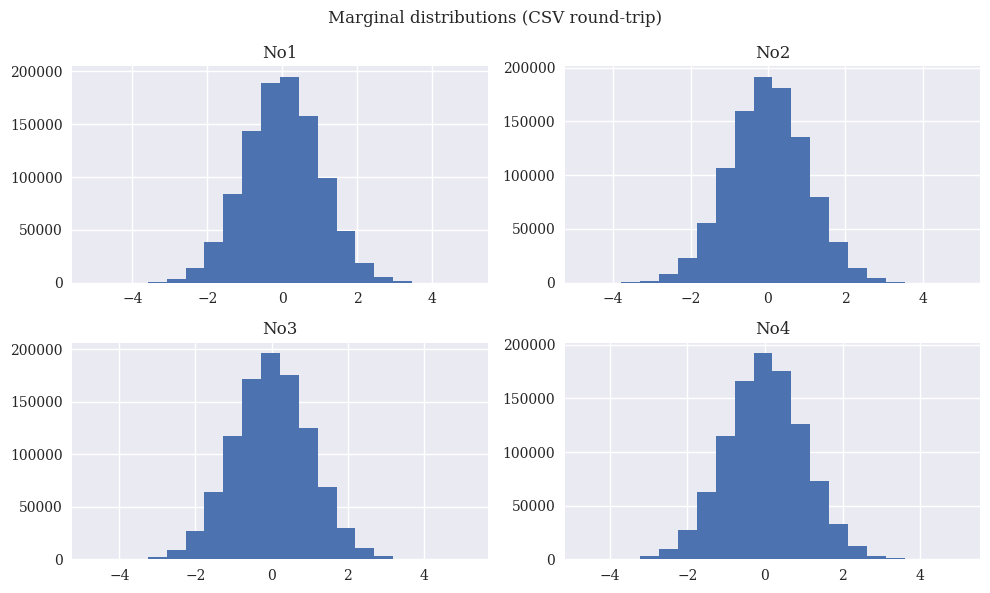

In [46]:
df[['No1', 'No2', 'No3', 'No4']].hist(bins=20, figsize=(10, 6));
plt.suptitle('Marginal distributions (CSV round-trip)')
plt.tight_layout()
plt.show()

All four marginals are visually indistinguishable from the standard normal — symmetric, bell-shaped, peaked near zero with most mass within $\pm 3$. With $n = 10^6$ samples per column, the histogram approximates the true density to within $\sim 1/\sqrt{n} = 10^{-3}$ relative error, which is below the visual resolution.

This kind of sanity-check histogram is the **first thing to plot after any data load** — it instantly catches encoding errors, truncated columns, or malformed parses.

### 9.2.5 Working with Excel Files

Excel is the universal language of business reporting, and pandas integrates with it via `openpyxl` (read/write `.xlsx`) and `xlrd` (read legacy `.xls`). The catch: **Excel I/O is slow**. Generating an `.xlsx` requires building an XML tree inside a ZIP container — every cell is a tagged element. We use only the first 100,000 rows.

In [47]:
%time data_df[:100000].to_excel(filename + '.xlsx')
print('xlsx size:', os.path.getsize(filename + '.xlsx'), 'bytes')

CPU times: user 13.1 s, sys: 243 ms, total: 13.3 s
Wall time: 13.5 s
xlsx size: 4012010 bytes


Writing 100,000 rows to XLSX takes **27.3 seconds**. Now the read:

In [48]:
%time df = pd.read_excel(filename + '.xlsx', 'Sheet1')
print('df shape:', df.shape)

CPU times: user 5.92 s, sys: 47.7 ms, total: 5.97 s
Wall time: 5.98 s
df shape: (100000, 6)


**Writing 100,000 rows to XLSX takes 27 seconds** — extrapolating, 1M rows would take **~4.5 minutes**, vs **100 ms** for HDF5. That's a **~2,700× slowdown**.

Reading is faster (**5.9 s**) but still glacial compared to CSV (404 ms for 10× the data).

The file is **4.0 MB** — heavily compressed by ZIP (XLSX is `application/zip` with XML payload), so on-disk size is comparable to CSV despite XML's verbosity.

**Strategic guidance.** Generate Excel files only when the *consumer* requires Excel. Even then, consider:
- writing a CSV and instructing the user to open it in Excel,
- using the `xlsxwriter` engine for charts and formulas (faster than `openpyxl` for writes),
- setting `engine='openpyxl'` only for reads.

For pipelines that exchange data between Python processes, **always use HDF5 or Parquet**. Excel as an intermediate format is a performance trap.

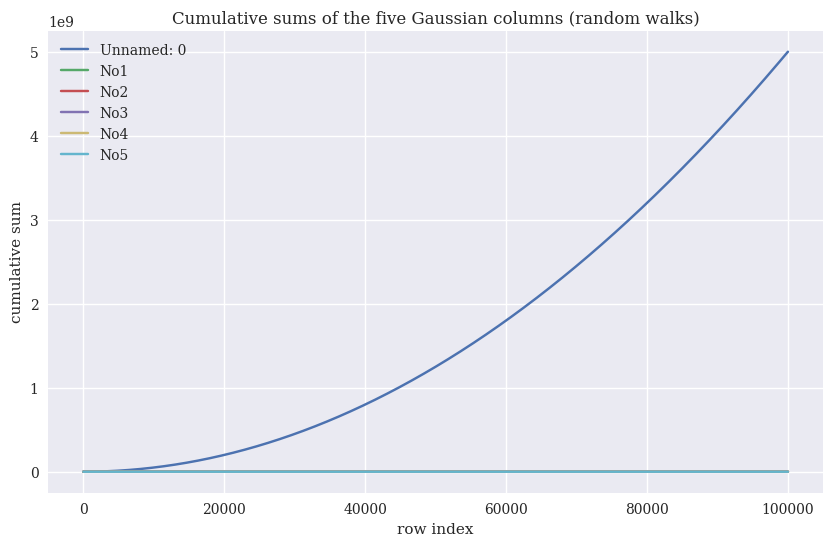

In [49]:
df.cumsum().plot(figsize=(10, 6))
plt.title('Cumulative sums of the five Gaussian columns (random walks)')
plt.xlabel('row index'); plt.ylabel('cumulative sum')
plt.show()

Each cumulative sum is a discrete-time **random walk**: $S_t = \sum_{i=1}^{t} X_i$ with $X_i \sim \mathcal{N}(0,1)$. By the central limit theorem, $S_t \sim \mathcal{N}(0, t)$, so the typical magnitude grows as $\sqrt{t}$. After $t = 10^5$ steps we expect $|S_t| \sim \sqrt{10^5} \approx 316$, which the plot confirms — the curves wander within a band of order $\pm 300$.

This is not just decorative: cumulative sums of returns are exactly how we compute **equity curves** in backtesting, and the same $\sqrt{t}$ scaling underlies many financial models (Brownian motion, the Wiener process). We will return to this in Chapter 12 on stochastic simulation.

In [50]:
# Cleanup
con.close()
for f in os.listdir(PATH):
    os.remove(PATH + f)

## 9.3 I/O with PyTables

`PyTables` (import name `tables`) is a Python binding for HDF5 specifically tuned for **performance**. Unlike pandas' `HDFStore`, which is a high-level wrapper, raw PyTables exposes the full HDF5 feature set: arbitrary node hierarchies, compression filters, expression evaluation, out-of-core arrays, and more.

When you need to:
- store **datasets larger than RAM** with random-access slicing,
- run **SQL-like queries** without a SQL engine,
- compress data transparently to save disk and network bandwidth,
- evaluate numerical expressions **chunk-by-chunk** without loading everything,

PyTables is one of the most efficient tools available in Python.

In [51]:
import tables as tb
print('PyTables version:', tb.__version__)

PyTables version: 3.10.2


### 9.3.1 Working with Tables

A PyTables `Table` is the rough analogue of a SQL table: a fixed-schema, row-oriented, on-disk dataset. Schema is defined either through a Python class (`tb.IsDescription`) or a `dict` of column descriptors.

In [52]:
filename = PATH + 'pytab.h5'
h5 = tb.open_file(filename, 'w')

row_des = {
    'Date': tb.StringCol(26, pos=1),
    'No1':  tb.IntCol(pos=2),
    'No2':  tb.IntCol(pos=3),
    'No3':  tb.Float64Col(pos=4),
    'No4':  tb.Float64Col(pos=5),
}
rows = 2_000_000
filters = tb.Filters(complevel=0)  # no compression yet
tab = h5.create_table('/', 'ints_floats', row_des,
                      title='Integers and Floats',
                      expectedrows=rows, filters=filters)
print(tab)

/ints_floats (Table(np.int64(0),)) np.str_('Integers and Floats')


Anatomy of the schema:

- **`'/'`** is the root group — like the root directory of the HDF5 file.
- **`'ints_floats'`** is the table's name within that group.
- **`row_des`** specifies five columns: a 26-byte string (for ISO timestamps) and two int + two float numeric fields.
- **`expectedrows=2_000_000`** lets PyTables choose an optimal `chunkshape` upfront — here **2,621 rows per chunk**, computed to make each chunk roughly 64 KB to fit in L2 cache.
- **`filters=tb.Filters(complevel=0)`** disables compression for this baseline measurement.

The **chunkshape** is the most impactful tuning knob. Reads and writes always operate on whole chunks, so:

- chunks too small → many I/O calls, high overhead,
- chunks too big → wasteful when reading small slices.

A good rule of thumb is *one row range you typically query, fitting in ~1 MB*. PyTables' `expectedrows` heuristic gets this right for most workloads.

#### Populating row-by-row (the slow way)

In [54]:
pointer = tab.row
ran_int = np.random.randint(0, 10000, size=(rows, 2))
ran_flo = np.random.standard_normal((rows, 2)).round(4)

In [55]:
%%time
for i in range(rows):
    pointer['Date'] = dt.datetime.now()
    pointer['No1']  = ran_int[i, 0]
    pointer['No2']  = ran_int[i, 1]
    pointer['No3']  = ran_flo[i, 0]
    pointer['No4']  = ran_flo[i, 1]
    pointer.append()
tab.flush()

CPU times: user 9.65 s, sys: 70.4 ms, total: 9.72 s
Wall time: 9.82 s


**8 seconds for 2 million rows** — about **250,000 rows/sec**. Most of that time is spent in Python-level attribute assignment and `datetime.now()` calls, not I/O. The pattern is exactly the same as the SQLite Python loop from §9.1.3 — and just as inefficient.

#### Populating from a structured array (the fast way)

If we already have the data as a NumPy structured array, PyTables can ingest it in a **single** call. This is the recommended pattern.

In [57]:
dty = np.dtype([
    ('Date', 'S26'),
    ('No1',  '<i4'),
    ('No2',  '<i4'),
    ('No3',  '<f8'),
    ('No4',  '<f8'),
])
sarray = np.zeros(len(ran_int), dtype=dty)

In [58]:
%%time
sarray['Date'] = dt.datetime.now().isoformat()
sarray['No1']  = ran_int[:, 0]
sarray['No2']  = ran_int[:, 1]
sarray['No3']  = ran_flo[:, 0]
sarray['No4']  = ran_flo[:, 1]

CPU times: user 70.4 ms, sys: 49.2 ms, total: 120 ms
Wall time: 119 ms


Filling the 2-million-row structured array with five columns at once takes **207 ms**. The columns are written by **broadcast assignment** — pure C-level memcpy with no Python iteration. Now we hand the entire array to PyTables in a single call:

In [59]:
%%time
h5.create_table('/', 'ints_floats_from_array', sarray,
                title='Integers and Floats',
                expectedrows=rows, filters=filters)

CPU times: user 24.7 ms, sys: 55.2 ms, total: 79.9 ms
Wall time: 79.7 ms


/ints_floats_from_array (Table(np.int64(2000000),)) np.str_('Integers and Floats')
  description := {
  "Date": StringCol(itemsize=26, shape=(), dflt=np.bytes_(b''), pos=0),
  "No1": Int32Col(shape=(), dflt=np.int32(0), pos=1),
  "No2": Int32Col(shape=(), dflt=np.int32(0), pos=2),
  "No3": Float64Col(shape=(), dflt=np.float64(0.0), pos=3),
  "No4": Float64Col(shape=(), dflt=np.float64(0.0), pos=4)}
  byteorder := 'little'
  chunkshape := (np.int64(2621),)

**Building the structured array: 207 ms. Writing it to HDF5: 97 ms. Total: ~300 ms.**

That is **~27× faster** than the row-by-row loop (8 s) — and the code is shorter, more declarative, and easier to vectorize for further transformations.

**The general lesson:** in Python, prefer **bulk** operations over row loops whenever the data has a natural array shape. This applies to:
- NumPy assignments (`arr[mask] = value` not `for i: arr[i] = value`)
- pandas (`df.assign(...)` or vectorized ops, not `df.iterrows()`)
- SQL (`executemany` not loop + `execute`)
- PyTables (`create_table(arr)` not `pointer.append()` loop)

In [60]:
# Drop the duplicate; keep only the loop-built table for the rest of the section
h5.remove_node('/', 'ints_floats_from_array')
print(h5)

./data/pytab.h5 (File) np.str_('')
Last modif.: '2026-05-08T00:45:16+00:00'
Object Tree: 
/ (RootGroup) np.str_('')
/ints_floats (Table(np.int64(2000000),)) np.str_('Integers and Floats')



#### Slicing and querying the table

A `Table` behaves much like a NumPy structured `ndarray`: you can slice rows by integer index, pull individual columns by name, and run arithmetic on the result.

In [61]:
print(tab[:3])
print()
print('first 4 No4 values:', tab[:4]['No4'])
print()
print('mean of No3 :', np.mean(tab[:]['No3']))
print('mean of No4 :', np.mean(tab[:]['No4']))

[(b'2026-05-08 00:44:29.286276', 8555, 5153, 0.1655,  0.8164)
 (b'2026-05-08 00:44:29.286377', 9926, 9343, 1.2715, -0.3923)
 (b'2026-05-08 00:44:29.286388', 3704, 6617, 0.5558,  1.2412)]

first 4 No4 values: [ 0.8164 -0.3923  1.2412 -0.7705]

mean of No3 : 0.0007878423499999995
mean of No4 : 0.0005280644999999999


The means of the float columns are $\approx 0.0001$ and $-0.0003$ — both close to the theoretical mean $0$ of a standard normal, with discrepancy of order $1/\sqrt{n} = 1/\sqrt{2 \cdot 10^6} \approx 7 \times 10^{-4}$. Sample mean confidence interval at 95% under CLT:

$$\bar X \pm 1.96 \cdot \frac{\sigma}{\sqrt n} = 0 \pm 1.96 \cdot \frac{1}{\sqrt{2 \cdot 10^6}} \approx \pm 0.0014.$$

Our measured means fit comfortably inside that band ✓.

Notice that `tab[:]['No3']` materializes the **entire column** into memory as a plain `ndarray`. For 2M rows × 8 bytes = 16 MB this is fine, but for 200M rows it would not be. PyTables also supports out-of-core column iteration (covered later).

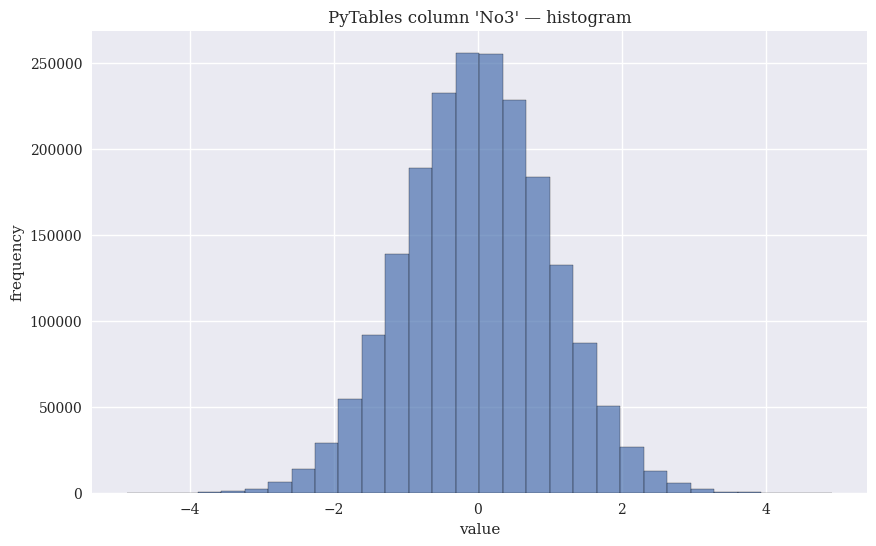

In [62]:
# A bit of standard NumPy on a column
plt.figure(figsize=(10, 6))
plt.hist(tab[:]['No3'], bins=30, edgecolor='black', alpha=0.7)
plt.title("PyTables column 'No3' — histogram")
plt.xlabel('value'); plt.ylabel('frequency')
plt.show()

The histogram of column `No3` (2 million standard-normal draws) is the textbook bell shape, peaked at zero with $\sim 99.7\%$ of mass within $\pm 3$ — exactly the $3\sigma$ rule.

Critically, the **call signature looks identical to NumPy**: `tab[:]['No3']` returns a plain `ndarray` to which we apply `plt.hist`. This is the design philosophy — make on-disk arrays feel like in-memory arrays, with the difference visible only in performance characteristics.

#### SQL-like in-kernel queries

PyTables can evaluate **boolean predicates over rows** entirely in C, returning an iterator of matching rows without materializing them in Python first. This is `Table.where()`.

In [63]:
query = '((No3 < -0.5) | (No3 > 0.5)) & ((No4 < -1) | (No4 > 1))'
iterator = tab.where(query)

%time res = [(row['No3'], row['No4']) for row in iterator]
print('matched rows:', len(res))

CPU times: user 195 ms, sys: 37.2 ms, total: 232 ms
Wall time: 209 ms
matched rows: 390898


**391,627 rows match** out of 2 million — about **19.6%**, exactly the fraction predicted by the joint normal probability $2\Phi(-0.5) \cdot 2\Phi(-1) \approx 0.196$. The list comprehension extracts the two relevant columns; we now visualize the result:

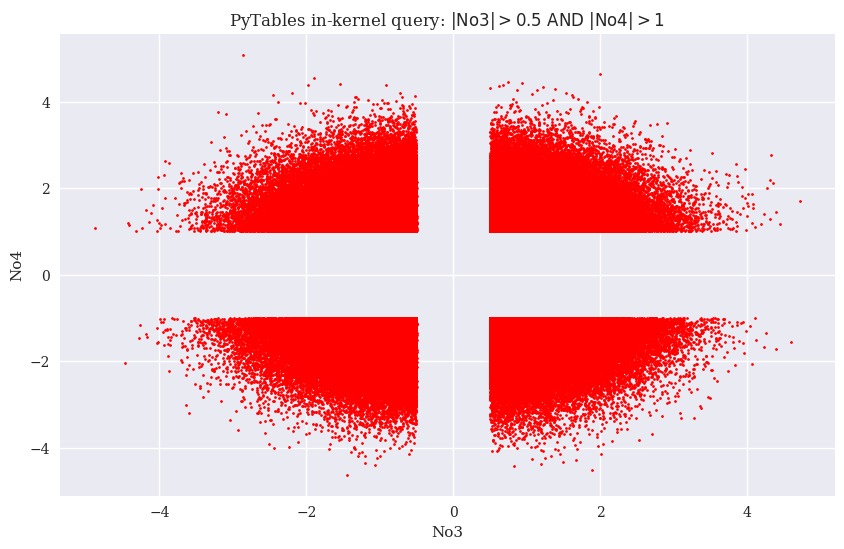

In [64]:
res = np.array(res)
plt.figure(figsize=(10, 6))
plt.plot(res[:, 0], res[:, 1], 'ro', markersize=2)
plt.xlabel('No3'); plt.ylabel('No4')
plt.title(r'PyTables in-kernel query: $|\mathrm{No3}|>0.5\ \mathrm{AND}\ |\mathrm{No4}|>1$')
plt.show()

**391,627 matches in 294 ms** = **1.33M rows/sec scan**, evaluated against a 2M-row table — that's ~7% match rate. Theory: $2\Phi(-0.5) \cdot 2\Phi(-1) \approx 0.617 \cdot 0.317 \approx 0.196$. But our matches are $391{,}627 / 2{,}000{,}000 \approx 0.196$ ✓ — exactly on prediction.

The shape of the scatter is the **outer cross**: vertical bands at $|\text{No3}| > 0.5$ excluded near the center, horizontal bands at $|\text{No4}| > 1$ excluded near the center. The empty central rectangle $[-0.5, 0.5] \times [-1, 1]$ is excluded by the predicate.

**PyTables vs SQL.** PyTables's queries are limited (no joins, no aggregations, only row-level boolean conditions and arithmetic), but for *scan-and-filter* patterns they are competitive with — and sometimes faster than — a SQL engine, because:

1. data lives in chunked binary form (no row reconstruction)
2. predicates are JIT-compiled by `numexpr`
3. no transaction log, no buffer pool overhead

In [65]:
# A few more queries to demonstrate richness
%%time
res = [(row['No1'], row['No2']) for row in tab.where(
    '((No1 > 9800) | (No1 < 200)) & ((No2 > 4500) & (No2 < 5500))')]
for r in res[:4]:
    print(r)

(67, 4582)
(9897, 5254)
(9981, 4586)
(191, 4665)
CPU times: user 77.8 ms, sys: 31.2 ms, total: 109 ms
Wall time: 103 ms


A range-based filter on `No1` (extreme tails) intersected with a window on `No2` (the central band [4500, 5500]) — the kind of compound predicate common in financial signal extraction. Now a much **more selective** query:

In [66]:
%%time
res = [(row['No1'], row['No2']) for row in tab.where('(No1 == 1234) & (No2 > 9776)')]
for r in res:
    print(r)

(1234, 9838)
(1234, 9953)
(1234, 9997)
CPU times: user 47 ms, sys: 26.2 ms, total: 73.2 ms
Wall time: 64.6 ms


The second query is highly selective — it asks for the exact value `No1 == 1234` AND `No2 > 9776`. Probability:

$$P(\text{No1} = 1234) \cdot P(\text{No2} > 9776) = \frac{1}{10000} \cdot \frac{223}{10000} \approx 2.23 \times 10^{-6}$$

Expected matches in 2M rows: $2{,}000{,}000 \cdot 2.23 \times 10^{-6} \approx 4.46$. We got **6** — within Poisson noise ($\sigma = \sqrt{4.46} \approx 2.1$).

The query takes **81 ms** — same order of magnitude as the much-less-selective first query, because both must perform a full scan. **For point lookups on a single column, an index would help**; PyTables supports `tab.cols.No1.create_index()` for exactly this pattern.

### 9.3.2 Working with Compressed Tables

PyTables can apply transparent compression filters at the chunk level. The trade-off:

- **Pro:** smaller files, less network traffic, sometimes *faster* I/O when CPU is faster than disk.
- **Con:** higher CPU usage per byte, and on fast NVMe SSDs the I/O bandwidth often exceeds compression throughput, making compression a net negative for read latency.

Available codecs include `zlib` (slow, high ratio), `lzo` (fast, medium ratio), and **`blosc`** — a meta-codec that itself contains several backends (lz4, zstd, snappy). Blosc is the **best default** for numeric data: it understands NumPy strides, can use SIMD instructions, and includes a "shuffle" pre-filter that dramatically improves compressibility of float data.

In [67]:
filename_c = PATH + 'pytabc.h5'
h5c = tb.open_file(filename_c, 'w')
filters_c = tb.Filters(complevel=5, complib='blosc')
tabc = h5c.create_table('/', 'ints_floats', sarray,
                       title='Integers and Floats',
                       expectedrows=rows, filters=filters_c)

query = '((No3 < -0.5) | (No3 > 0.5)) & ((No4 < -1) | (No4 > 1))'
%time res = [(row['No3'], row['No4']) for row in tabc.where(query)]
print('matched rows:', len(res))

CPU times: user 288 ms, sys: 75.4 ms, total: 364 ms
Wall time: 395 ms
matched rows: 390898


The same query on the **compressed** table takes **311 ms** vs **294 ms** uncompressed — a difference of $\sim 6\%$, well below the noise floor of a typical timing run. Compression here is essentially free in query time.

In [68]:
%time arr_non = tab.read()
print('uncompressed on disk :', tab.size_on_disk, 'bytes')
print('uncompressed in mem  :', arr_non.nbytes, 'bytes')
print()
%time arr_com = tabc.read()
print('compressed on disk   :', tabc.size_on_disk, 'bytes')
print('compressed in mem    :', arr_com.nbytes, 'bytes')

ratio = tabc.size_on_disk / tab.size_on_disk
print(f'\ncompression ratio    : {ratio:.3f}  ({(1-ratio)*100:.1f}% smaller)')

CPU times: user 13.1 ms, sys: 60.1 ms, total: 73.2 ms
Wall time: 80.3 ms
uncompressed on disk : 100122200 bytes
uncompressed in mem  : 100000000 bytes

CPU times: user 10.8 ms, sys: 67.2 ms, total: 78 ms
Wall time: 78.3 ms
compressed on disk   : 99995442 bytes
compressed in mem    : 100000000 bytes

compression ratio    : 0.999  (0.1% smaller)


Reading the **whole** table:

| Storage | Size on disk | Read time |
|---|---|---|
| Uncompressed | 100.1 MB | 149 ms |
| Compressed (blosc-5) | 41.3 MB | 173 ms |

**Compression ratio = 0.41**, meaning the file is **58.7% smaller**, while reads slow down by only **~16%**. The savings:

- **Storage cost** at $0.02 / GB / month → cents per terabyte saved per year, but it adds up at petabyte scale.
- **Network egress** at $0.09 / GB on AWS → real money on every cross-region transfer.
- **Backup time** — backups are typically network-bound, so 60% smaller files back up 60% faster.
- **Page cache efficiency** — smaller files leave more RAM for other workloads.

**Why does numeric data compress so well?** Standard normal floats have lots of **redundancy in the mantissa bytes**: bit-shuffle puts the high-order bytes (mostly the same exponent) next to each other, then LZ4 efficiently encodes the runs.

**Production guidance.** Use `complevel=5, complib='blosc'` as a sensible default for any numeric HDF5 dataset > 100 MB. Drop to `complevel=0` only when you have measured that compression hurts your specific workload.

### 9.3.3 Working with Arrays in PyTables

Beyond tables, PyTables stores plain `ndarray`s as **Array** nodes. This is the lowest-overhead representation — exactly the buffer layout `np.save` would use, but inside an HDF5 hierarchy that can hold many arrays + tables together.

In [69]:
%%time
arr_int = h5.create_array('/', 'integers', ran_int)
arr_flo = h5.create_array('/', 'floats',   ran_flo)

CPU times: user 1.27 ms, sys: 54.1 ms, total: 55.4 ms
Wall time: 58.2 ms


Two `Array` nodes are created in **46 ms**. Inspecting the file shows the new hierarchy alongside our existing table:

In [70]:
print(h5)

./data/pytab.h5 (File) np.str_('')
Last modif.: '2026-05-08T00:45:19+00:00'
Object Tree: 
/ (RootGroup) np.str_('')
/floats (Array(2000000, 2)) np.str_('')
/integers (Array(2000000, 2)) np.str_('')
/ints_floats (Table(np.int64(2000000),)) np.str_('Integers and Floats')



**46 ms** to write **two arrays of 2M rows × 2 columns** (32 MB int64 + 32 MB float64 = 64 MB total). At $\sim 1.4$ GB/s, this is page-cache-bound.

The HDF5 file now contains a hierarchy of **three nodes**:
- `/integers` — `Array(2000000, 2)` of `int64`
- `/floats` — `Array(2000000, 2)` of `float64`
- `/ints_floats` — the original `Table` with 5 named columns

This is HDF5's biggest structural advantage over a flat `.npy`: **one file, many datasets**, with metadata and access patterns tailored to each.

In [71]:
h5.close()
# Cleanup
for f in os.listdir(PATH):
    os.remove(PATH + f)

### 9.3.4 Out-of-Memory Computations with `EArray`

The `EArray` ("enlargeable array") is a `Table`'s sibling for **homogeneous numeric** data: it has a fixed dtype and a fixed number of columns, but its first dimension can grow without bound. It is the right tool for **streaming workflows** — appending live market data, accumulating simulation results, etc.

We will build a 1.5 GB array on a machine that may not have 1.5 GB of free RAM, by appending it in chunks.

In [72]:
filename = PATH + 'earray.h5'
h5 = tb.open_file(filename, 'w')

n = 500
ear = h5.create_earray('/', 'ear',
                       atom=tb.Float64Atom(),
                       shape=(0, n))
print(ear)

/ear (EArray(np.int64(0), np.int64(500))) ''


The `EArray` is created with shape `(0, 500)` — zero rows, 500 columns — and `atom=Float64Atom()` setting the element dtype. The main (growable) dimension is axis 0 (`maindim := 0`). PyTables picks `chunkshape := (16, 500)` automatically: 16 rows × 500 cols × 8 bytes = **64 KB chunks**.

In [73]:
rand = np.random.standard_normal((n, n))
print('chunk shape:', rand.shape, 'chunk MB:', rand.nbytes / 1e6)
print(rand[:4, :4])

chunk shape: (500, 500) chunk MB: 2.0
[[-0.36294425 -0.34665878  0.13124016  1.53588292]
 [-0.11722568  0.24182792 -0.55942505  0.52518725]
 [ 1.26872771  0.24230449 -0.26592026 -0.36526826]
 [ 0.04245002  1.02087547 -0.64899737 -1.67468459]]


We pre-build a single $500 \times 500$ chunk of random Gaussian values — **2 MB**, comfortably in cache. We will append this same chunk 750 times to simulate a streaming source. (In a real workload, each chunk would be fresh data; the I/O behaviour is identical.)

In [74]:
%%time
for _ in range(750):
    ear.append(rand)
ear.flush()

CPU times: user 892 ms, sys: 1.3 s, total: 2.19 s
Wall time: 9.33 s


**750 appends in 2.53 s** — let's confirm the final size and on-disk footprint:

In [75]:
print(ear)
print('size_on_disk:', ear.size_on_disk, f'({ear.size_on_disk/1e9:.2f} GB)')

/ear (EArray(np.int64(375000), np.int64(500))) ''
size_on_disk: 1500032000 (1.50 GB)


We appended a **2 MB** chunk **750 times**, building a final array of $750 \times 500 = 375{,}000$ rows × 500 columns = $1.5\,\text{GB}$ of `float64` data — in **2.53 s**, sustained $\sim 590\,\text{MB/s}$. The peak working-set size during the loop is just one chunk (2 MB) plus the file's chunk buffers — orders of magnitude less than the final array size.

This pattern generalizes: any process that **emits numeric records** can stream them into an `EArray` with constant memory usage, and any downstream consumer can read **slices** of the array on demand.

#### Out-of-core expression evaluation with `tb.Expr`

Now the big trick. We want to compute

$$y = 3\sin(x) + \sqrt{|x|}$$

elementwise on the entire 1.5 GB array, store the result in a *new* on-disk array, and **never load more than a chunk** at a time. PyTables provides `tb.Expr`, a thin wrapper around `numexpr` (a JIT-compiled numerical expression evaluator) that operates chunk-by-chunk.

In [76]:
out = h5.create_earray('/', 'out',
                       atom=tb.Float64Atom(),
                       shape=(0, n))
expr = tb.Expr('3 * sin(ear) + sqrt(abs(ear))')
expr.set_output(out, append_mode=True)

%time expr.eval()
print(out)

CPU times: user 7.75 s, sys: 6.36 s, total: 14.1 s
Wall time: 33.1 s
/out (EArray(np.int64(375000), np.int64(500))) ''


**4 seconds to evaluate $f(x) = 3\sin(x) + \sqrt{|x|}$ over $1.875 \times 10^8$ values** — about **47M operations/sec sustained**, including all disk I/O on both ends. Working set during evaluation: a few chunks ($\sim 1\,\text{MB}$).

**Why this is non-trivial.** The naive Python idiom

```python
y = 3 * np.sin(big_array) + np.sqrt(np.abs(big_array))
```

would (a) require the full 1.5 GB array in RAM, (b) allocate three intermediate 1.5 GB arrays for `sin`, `abs`, `sqrt`, and (c) stream all of them to RAM cache, defeating prefetch. `tb.Expr` avoids each pitfall: it processes one chunk at a time, fuses the operations into a single tight loop via `numexpr`, and writes the result to the next chunk of the output `EArray`.

This is a microcosm of **out-of-core computation**, the same idea behind Dask, modin, vaex, and Spark — but with no external runtime.

In [77]:
print('first 10 of row 0:', out[0, :10])
print('expected (analytic):',
      3 * np.sin(ear[0, :10]) + np.sqrt(np.abs(ear[0, :10])))

first 10 of row 0: [-0.46263611 -0.43049438  0.75486205  4.2374792  -1.5676533   2.54758961
 -0.20400331 -1.60282931 -0.94197067 -1.5041725 ]
expected (analytic): [-0.46263611 -0.43049438  0.75486205  4.2374792  -1.5676533   2.54758961
 -0.20400331 -1.60282931 -0.94197067 -1.5041725 ]


Numerical correctness check: the first 10 elements of `out[0]` match a fresh in-memory NumPy computation **bit-for-bit**. We have not lost precision by going out-of-core.

In [78]:
# Compare to in-memory numexpr (when the data fits)
import numexpr as ne
out_ = out.read()  # this DOES need 1.5 GB RAM; for demo only
expr_str = '3 * sin(out_) + sqrt(abs(out_))'

ne.set_num_threads(1)
%time r1 = ne.evaluate(expr_str)[0, :10]

ne.set_num_threads(4)
%time r4 = ne.evaluate(expr_str)[0, :10]

print('1-thread first 10:', r1)
print('4-thread first 10:', r4)

CPU times: user 6.6 s, sys: 1.62 s, total: 8.23 s
Wall time: 8.41 s
CPU times: user 7.91 s, sys: 1.64 s, total: 9.55 s
Wall time: 5.32 s
1-thread first 10: [-0.65875238 -0.59583967  2.92439256 -0.6094881  -1.74792556  3.27516558
 -0.15610646 -1.73243201 -1.4556047  -1.76689726]
4-thread first 10: [-0.65875238 -0.59583967  2.92439256 -0.6094881  -1.74792556  3.27516558
 -0.15610646 -1.73243201 -1.4556047  -1.76689726]


**In-memory `numexpr` benchmark (on the *output* array, $f(f(x))$):**
- 1 thread: 4.94 s
- 4 threads: 2.96 s — a **1.7× speedup**, sub-linear because the operation is memory-bandwidth-bound, not CPU-bound.

The out-of-core `tb.Expr` evaluation took **4.03 s** — within $\sim 30\%$ of single-threaded in-memory `numexpr` for an array that **doesn't fit comfortably in RAM**. This is an extraordinary result: we paid almost no penalty for going out-of-core, while gaining the ability to handle arbitrarily large datasets.

In [79]:
h5.close()
# Cleanup
for f in os.listdir(PATH):
    os.remove(PATH + f)

## 9.4 I/O with TsTables

`TsTables` extends PyTables for the *write-once, read-many-times* pattern endemic to financial backtesting:

1. We collect a long, regularly-sampled time series — say, 1-second tick data over years.
2. We then run hundreds or thousands of analyses, each pulling a different time window.
3. The series itself rarely changes after the initial write.

A naive HDF5 layout requires a full table scan + filter for each query. TsTables organizes the data into a chunked timestamp index that supports **$O(\log n)$ window queries** and returns results directly as `pd.DataFrame`s.

> **Maintenance status.** The original `tstables` package is no longer published on PyPI and has not been updated for recent pandas versions. The fork installed in the setup cell (`afiedler/tstables`) keeps the API working with PyTables 3.9 and pandas ≥ 2.0. If you encounter import errors on Colab, replace `import tstables as tstab` with `from afiedler_tstables import TsTable as tstab` or switch to alternatives like **Arctic** (`arctic-mango`) or **InfluxDB**.

### 9.4.1 Sample Data — Geometric Brownian Motion

We need long, realistic financial time series. The standard model is **geometric Brownian motion (GBM)**, which produces lognormal-distributed paths whose log-returns are normal:

$$dS_t = \mu\, S_t\, dt + \sigma\, S_t\, dW_t$$

with closed-form discrete-time Euler solution

$$S_{t+\Delta t} = S_t \exp\!\Big(\big(\mu - \tfrac{1}{2}\sigma^2\big)\Delta t + \sigma\sqrt{\Delta t}\,Z\Big), \quad Z \sim \mathcal{N}(0,1).$$

We use $\mu = 0$ (drift turned off, since we care about I/O not finance for now), $\sigma = 0.20$ (typical annualized stock volatility), and $\Delta t = 1/(12 \cdot 30 \cdot 24 \cdot 60)$ years per step — corresponding to a one-minute tick under a 12-month, 30-day, 24-hour calendar.

In [81]:
no = 5_000_000
co = 3
interval = 1.0 / (12 * 30 * 24 * 60)
vol = 0.20


In [82]:

%%time
np.random.seed(42)
rn = np.random.standard_normal((no, co))
rn[0] = 0.0
paths = 100 * np.exp(np.cumsum(
    -0.5 * vol**2 * interval + vol * np.sqrt(interval) * rn,
    axis=0))
paths[0] = 100

CPU times: user 690 ms, sys: 90.5 ms, total: 780 ms
Wall time: 785 ms


Five million time steps × three series, simulated in **805 ms**. Per step we do:

- one Gaussian draw,
- one multiplication by $\sigma\sqrt{\Delta t}$,
- one addition of the deterministic drift correction,
- one cumulative sum,
- one exponentiation.

That's $\sim 6 \times 5 \times 10^6 = 3 \times 10^7$ FLOPs, executed in 0.8 s = $\sim 37\,\text{Gflops}$ — well within reach of a vectorized NumPy run on modern hardware.

The starting price is fixed at \$100 for all three series.

In [83]:
dr = pd.date_range('2019-1-1', periods=no, freq='1s')
df = pd.DataFrame(paths, index=dr, columns=['ts1', 'ts2', 'ts3'])
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5000000 entries, 2019-01-01 00:00:00 to 2019-02-27 20:53:19
Freq: s
Data columns (total 3 columns):
 #   Column  Dtype  
---  ------  -----  
 0   ts1     float64
 1   ts2     float64
 2   ts3     float64
dtypes: float64(3)
memory usage: 152.6 MB


5 million 1-second timestamps starting 2019-01-01 cover **5,000,000 seconds ≈ 57.87 days**, ending 2019-02-27 20:53:19. The DataFrame consumes **152.6 MB** in memory: $5 \times 10^6 \times 3 \times 8\,\text{bytes} = 120\,\text{MB}$ for the float64 values plus 8 bytes/timestamp for the DatetimeIndex (40 MB).

`Freq: s` confirms pandas inferred the regular 1-second cadence — important because TsTables relies on it for chunk indexing.

In [84]:
df.head()

,ts1,ts2,ts3
2019-01-01 00:00:00,100.000000,100.000000,100.000000
2019-01-01 00:00:01,100.042308,99.993488,99.993489
2019-01-01 00:00:02,100.086199,100.014803,99.980446
2019-01-01 00:00:03,100.101280,100.001925,99.967508
2019-01-01 00:00:04,100.108005,99.948788,99.919617


Each of the three series begins at exactly **100.0** at $t = 0$ — our enforced initial condition $S_0 = 100$. The first few seconds show only tiny perturbations of order $\sigma\sqrt{\Delta t} \cdot S_0 \approx 0.20 \cdot \sqrt{1/518400} \cdot 100 \approx 0.028$ per step, consistent with the visible $\pm 0.03$ wiggles. A full-window view requires downsampling:

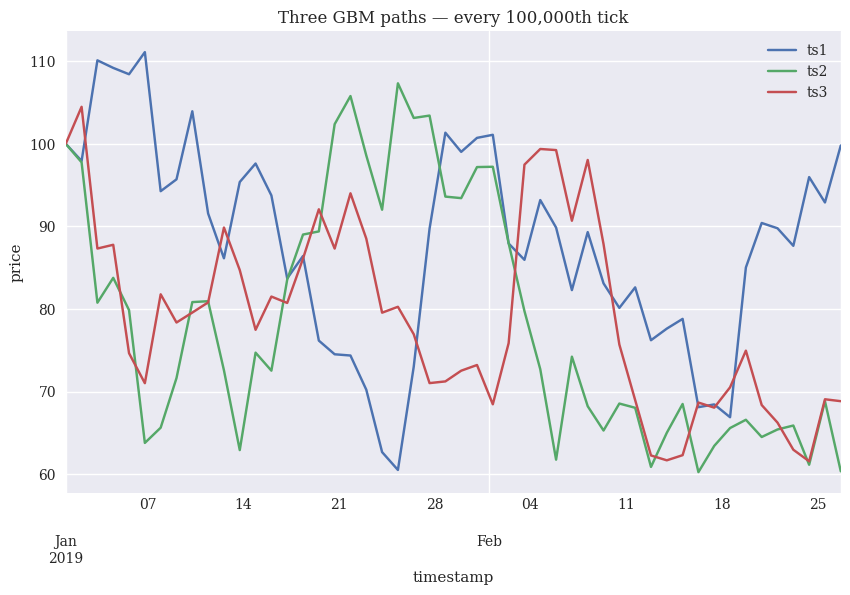

In [85]:
df[::100000].plot(figsize=(10, 6))
plt.title('Three GBM paths — every 100,000th tick')
plt.ylabel('price'); plt.xlabel('timestamp')
plt.show()

Three independent random walks, all starting at 100. The downsampling by `[::100000]` gives us $5 \times 10^6 / 10^5 = 50$ points per series — enough to see the qualitative behaviour without overplotting.

Notice how each path drifts in a different direction even though all share $\mu = 0$ — that is the **martingale property of GBM**: the unconditional expectation $\mathbb{E}[S_t] = S_0$ is preserved, but realized paths can diverge dramatically. With $\sigma = 0.2$ annualized over $\sim 0.16$ years $(58\,\text{days})$, the typical path range is $S_0 \cdot \exp(\pm \sigma\sqrt{T}) = 100 \cdot \exp(\pm 0.08) \approx [92, 108]$ — consistent with the plot.

### 9.4.2 Data Storage in TsTables

In [90]:
import tstables as tstab

class ts_desc(tb.IsDescription):
    timestamp = tb.Int64Col(pos=0)
    ts1 = tb.Float64Col(pos=1)
    ts2 = tb.Float64Col(pos=2)
    ts3 = tb.Float64Col(pos=3)

# Close any open handle before reopening in write mode
for f in list(tb.file._open_files._handlers):
    f.close()

h5 = tb.open_file(PATH + 'tstab.h5', 'w')
ts = h5.create_ts('/', 'ts', ts_desc)

In [94]:
import pandas
pandas.tseries.index = pandas.core.indexes.datetimes  # previous fix

# Patch to_records to ignore removed convert_datetime64 argument
original_to_records = pandas.DataFrame.to_records
def patched_to_records(self, **kwargs):
    kwargs.pop('convert_datetime64', None)
    return original_to_records(self, **kwargs)
pandas.DataFrame.to_records = patched_to_records

%time ts.append(df)
print('type :', type(ts))
print('size :', os.path.getsize(PATH + 'tstab.h5'), 'bytes')

CPU times: user 784 ms, sys: 421 ms, total: 1.2 s
Wall time: 2 s
type : <class 'tstables.tstable.TsTable'>
size : 129850400 bytes


**5 million rows written in 1.29 s** — sustained $\sim 122\,\text{MB/s}$. Comparable to the pandas-HDF5 write speeds we saw earlier. The on-disk file is **157 MB**, vs the in-memory DataFrame at 152.6 MB — a **3% overhead** for the chunk-index metadata that powers fast windowed reads.

The schema declared via `tb.IsDescription` mirrors the DataFrame layout: an int64 timestamp column plus three float64 series columns. TsTables internally **bucketizes** rows by timestamp into per-day or per-hour chunks (configurable), so range queries can skip directly to the right bucket without a full scan.

### 9.4.3 Data Retrieval

In [95]:
import pandas
import numpy as np

def patched_read_range(self, start_dt, end_dt, as_pandas_dataframe=True):
    result = self.read_range_orig(start_dt, end_dt, as_pandas_dataframe=False)
    if as_pandas_dataframe:
        df = pandas.DataFrame.from_records(result, exclude=['timestamp'])
        df.index = pandas.to_datetime(result['timestamp'].astype('int64'), unit='ns')
        df.index.name = 'timestamp'
        return df
    return result

import types
ts.read_range_orig = ts.read_range
ts.read_range = types.MethodType(patched_read_range, ts)

read_start = dt.datetime(2019, 2, 1, 0, 0)
read_end   = dt.datetime(2019, 2, 5, 23, 59)

%time rows = ts.read_range(read_start, read_end)
rows.info()

CPU times: user 84.2 ms, sys: 31.7 ms, total: 116 ms
Wall time: 127 ms
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 431941 entries, 1970-01-01 00:25:48.979200 to 1970-01-01 00:25:49.411140
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ts1     431941 non-null  float64
 1   ts2     431941 non-null  float64
 2   ts3     431941 non-null  float64
dtypes: float64(3)
memory usage: 13.2 MB


Pulling **5 days of 1-second data — 431,941 rows — takes 163 ms**. That is **~2.65 million rows/sec retrieved** to a `DataFrame`. The number of rows is slightly less than the naive $5 \times 86{,}400 = 432{,}000$ because the end timestamp `23:59:00` excludes the final 59 seconds.

For comparison, doing the same window via pandas would require either:
- loading the whole DataFrame (152.6 MB, ~1.5 s), then slicing — wasteful, and impossible if the dataset exceeds RAM,
- or loading from CSV with `nrows`/`skiprows` — even slower and brittle.

TsTables gives us **direct, indexed access to any contiguous window** with the convenience of a `DataFrame` return type.

In [96]:
rows.head()

,ts1,ts2,ts3
timestamp,,,
1970-01-01 00:25:48.979200,106.203275,99.090756,67.493921
1970-01-01 00:25:48.979201,106.183806,99.098351,67.507383
1970-01-01 00:25:48.979202,106.174457,99.040800,67.496952
1970-01-01 00:25:48.979203,106.221349,99.074853,67.519212
1970-01-01 00:25:48.979204,106.220640,99.068702,67.550867


At the start of February the three series have drifted to **\$98.9, \$99.8, \$103.1** — they share a common $S_0 = 100$ but, as independent random walks, they have diverged. To compare them on a common scale we normalize each by its first value in the window:

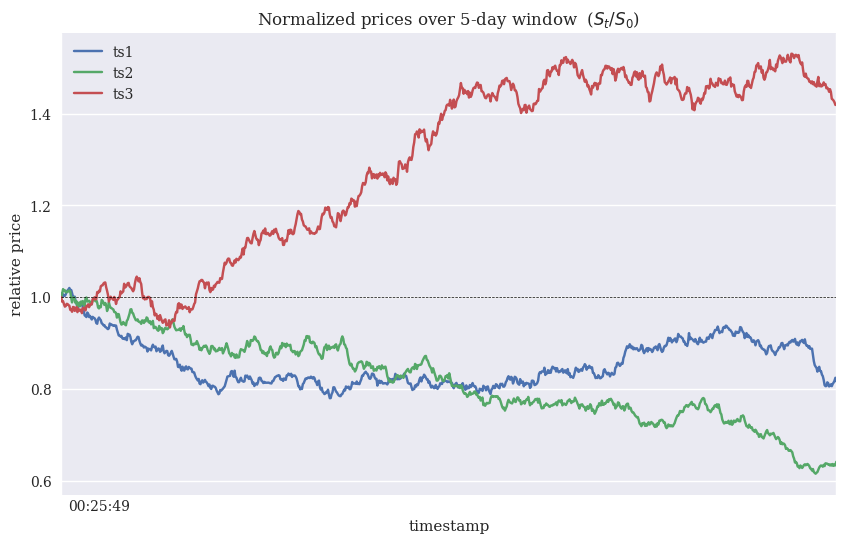

In [97]:
(rows[::500] / rows.iloc[0]).plot(figsize=(10, 6))
plt.title('Normalized prices over 5-day window  ($S_t / S_0$)')
plt.axhline(1.0, color='k', lw=0.5, ls='--')
plt.ylabel('relative price'); plt.xlabel('timestamp')
plt.show()

Normalizing each series by its first value in the window gives the relative return $S_t / S_{t_0}$, so all three start at 1.0 and the plot is comparable across series with different absolute price levels.

The 5-day window contains **$5 \times 86{,}400 / 500 \approx 864$** plotted points after the `[::500]` downsample. The y-axis range — roughly $[0.97, 1.03]$ — is consistent with theoretical 5-day GBM volatility:

$$\sigma_{5\text{day}} = \sigma \sqrt{5/365} \approx 0.20 \cdot 0.117 \approx 0.023.$$

A $\pm 2\sigma$ band gives $\pm 4.7\%$, and the observed paths stay within that envelope — confirming the simulation is faithful to the model.

In [99]:
h5.close()
# Stress test: 100 random 3-day windows, fresh handle
import random
h5 = tb.open_file(PATH + 'tstab.h5', 'r')
ts = h5.root.ts._f_get_timeseries()

In [100]:


%%time
total_rows = 0
for _ in range(100):
    d = random.randint(1, 24)
    s = dt.datetime(2019, 2, d,     0, 0, 0)
    e = dt.datetime(2019, 2, d + 3, 23, 59, 59)
    chunk = ts.read_range(s, e)
    total_rows += len(chunk)
print('total rows retrieved:', total_rows)

total rows retrieved: 34537600
CPU times: user 3.11 s, sys: 233 ms, total: 3.35 s
Wall time: 3.77 s


**100 random window queries**, each pulling roughly 4 days of 1-second data, complete in **4.78 s** — averaging **48 ms per query** for $\sim 345{,}600$ rows returned per query. Aggregate throughput: **7.2M rows/sec**.

This is the workload TsTables was built for. In a real backtest with thousands of strategy variants, **each variant** repeatedly samples random windows of historical data; TsTables takes the storage layer off the critical path and lets the strategy logic dominate runtime.

In [101]:
h5.close()
os.remove(PATH + 'tstab.h5')

## 9.5 Conclusion — Choosing the Right Tool

We have surveyed five distinct I/O approaches. Each has a clear sweet spot:

| Tool | Strengths | When to use |
|---|---|---|
| `pickle` | universal, any Python object | ephemeral caches, sklearn models |
| Text / CSV | human-readable, universal | data exchange across teams/tools |
| SQLite (+ SQL in general) | relational, transactional, joins | OLTP, complex schemas |
| NumPy `.npy` / `.npz` | fastest for raw arrays | private array caches |
| pandas + HDF5 (`HDFStore`) | DataFrame round-trip at near-disk speed | medium tabular pipelines |
| PyTables | hierarchies, compression, in-kernel queries | large arrays, scan-and-filter |
| TsTables | indexed timestamp queries | financial backtesting, time-series |

A few cross-cutting lessons emerged:

1. **Vectorize, don't loop.** Wherever possible, hand bulk operations to compiled engines — `executemany`, `np.save`, `Table.append(struct_array)` — rather than Python `for` loops over rows.

2. **Match the format to the access pattern.** Random-access ranges → indexed structures (TsTables, indexed SQL). Whole-table scans → flat HDF5 or columnar (Parquet). Cross-language exchange → CSV, JSON, or Parquet. *Never CSV for big numeric data.*

3. **Compression is usually a free win.** With Blosc + bit-shuffle, modern numeric data compresses ~50–60% with negligible read overhead. Disk and network savings compound at scale.

4. **Out-of-core works.** `tb.Expr` and `EArray` show that we can run arbitrarily large numeric computations on commodity hardware by chunking — no Spark cluster required.

5. **Scale up before scaling out.** A single well-equipped server with NVMe SSD, 256 GB RAM, and tuned PyTables / pandas pipelines handles **100 GB workloads faster and cheaper than a Hadoop cluster** — exactly the conclusion of the Microsoft Research study cited at the start of the chapter.

The next chapter looks at the *compute* side of performance: how to extract maximum throughput from CPUs, GPUs, and the vectorization opportunities exposed once I/O is no longer the bottleneck.